    ## Master in Artificial Intelligence, UdC, USC, UVigo. 2025/2026
## COMPUTER VISION I

### Lab 5
### Topic 4: Image Segmentation
### Part 2: Morphological operations and region growing (1.40 pts.)

---

### Learning Objectives

In this lab, you will learn:

1. **Morphological Operations Fundamentals** - Erosion, dilation, opening, closing
2. **Structuring Elements** - How kernel shape and size affects results
3. **Optical Character Recognition (OCR) Preprocessing** - Using morphology to improve text recognition
4. **Region Growing Segmentation** - Seed-based image segmentation
5. **Morphological Post-processing** - Using morphology to clean segmentation results
6. **Example of real application** - Computing physical measurements (e.g. area, volume) from segmentations

---

#### Important: Morphological Operations Work on Binary Images

A critical concept: **morphological operations are designed for binary images** (black and white only). They work by analyzing the **structure** of foreground/background regions:

- **Erosion**: Shrinks white regions (foreground)
- **Dilation**: Expands white regions (foreground)
- **Opening**: Erosion followed by dilation - removes small white noise
- **Closing**: Dilation followed by erosion - fills small black holes

Morphology cannot directly fix grayscale degradation like stains or uneven lighting. For those problems, you need **binarization** first (converting grayscale to binary), then morphology for **post-processing**.

---

### Setup

In [17]:
# Standard imports
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

# Force reload of lab5_utils to get latest version
from lab5_utils import (
    visualize_structuring_elements,
    compare_morphological_ops,
    add_salt_noise,
    add_pepper_noise,
    apply_stroke_erosion,
    create_clean_text_image,
    # SVHN dataset functions
    load_svhn_cropped,
    prepare_svhn_for_morphology,
    # SVHN pipeline evaluation
    evaluate_morphological_pipeline,
    # Region growing and segmentation
    visualize_region_growing,
    make_similarity_criterion,
    compute_region_areas,
    merge_regions,
)

# Morphological operations from skimage

# Set random seed for reproducibility
np.random.seed(42)

# Define paths
images_path = 'images'
svhn_path = 'data/test_32x32.mat'
mri_image_path = 'data/brain_MRI_GM2.png'

print("Setup complete!")
print(f"SVHN dataset available: {os.path.exists(svhn_path)}")
print(f"MRI example data available: {os.path.exists(mri_image_path)}")

Setup complete!
SVHN dataset available: True
MRI example data available: True


---

## Morphological Operations Fundamentals

### Background: Structuring Elements

A **structuring element** (or kernel) is a small binary matrix that defines the neighborhood examined during morphological operations. The shape of the structuring element determines what structures are preserved or removed. The most common shapes are:
- **Rectangle**: General-purpose, affects all directions equally
- **Ellipse**: Smoother results, less corner artifacts
- **Cross**: Preserves horizontal and vertical structures

### Exercise 1: Create Structuring Elements

Create three 5x5 structuring elements: rectangle, ellipse, and cross.

**Hint**: Use `cv2.getStructuringElement()` with:
- `cv2.MORPH_RECT` for rectangle
- `cv2.MORPH_ELLIPSE` for ellipse  
- `cv2.MORPH_CROSS` for cross

In [18]:
def create_structuring_elements(size=5):
    """
    Create three structuring elements of the given size.
    
    Args:
        size: Size of the structuring elements (default 5)
    
    Returns:
        tuple: (kernel_rect, kernel_ellipse, kernel_cross)
    """

    # YOUR CODE HERE
    # Rectangle structuring element: fills the whole kernel
    kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    
    # Ellipse structuring element: approximates an ellipse/circle
    kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))
    
    # Cross structuring element: plus-shaped (+)
    kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))
    
    return kernel_rect, kernel_ellipse, kernel_cross

Question 1 validation passed!


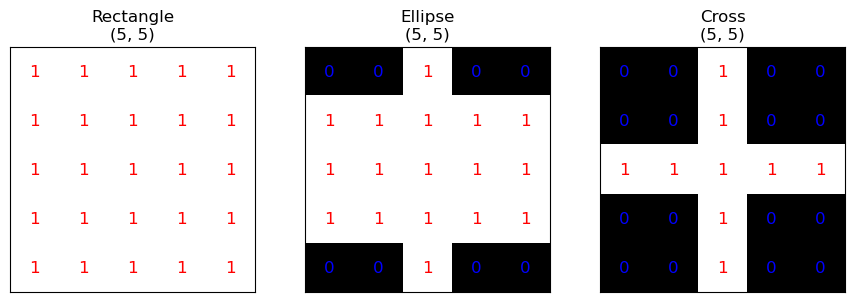

In [19]:
# Test your implementation
kernel_rect, kernel_ellipse, kernel_cross = create_structuring_elements(5)

# Validation
assert kernel_rect is not None and kernel_rect.shape == (5, 5), "Rectangle kernel should be 5x5"
assert kernel_ellipse is not None and kernel_ellipse.shape == (5, 5), "Ellipse kernel should be 5x5"
assert kernel_cross is not None and kernel_cross.shape == (5, 5), "Cross kernel should be 5x5"
assert kernel_rect.sum() == 25, "Rectangle should have all 1s"
assert kernel_cross.sum() == 9, "5x5 Cross should have 9 ones"

print("Question 1 validation passed!")

# Visualize the kernels
visualize_structuring_elements(
    [kernel_rect, kernel_ellipse, kernel_cross],
    ['Rectangle', 'Ellipse', 'Cross']
)

### Exercise 2: Erosion
Implement erosion: look for the function in Opencv that applies erosion to a binary image and complete the following `apply_erosion` function. Then, use the provided code to create a test image with text and apply erosion with different kernels. You may also want to compute new kernels (e.g. with different sizes) to better observe the impact of the kernel size.

**Erosion** shrinks white (foreground) regions by removing pixels at boundaries. A pixel remains white only if ALL pixels under the structuring element are white.

In [20]:
def apply_erosion(image, kernel, iterations=1):
    """
    Apply erosion to a binary image.
    
    Args:
        image: Binary input image
        kernel: Structuring element
        iterations: Number of times to apply erosion
    
    Returns:
        np.array: Eroded image
    """

    # YOUR CODE HERE
    # Apply erosion using OpenCV function
    # src: input image, kernel: structuring element, iterations: how many times to repeat
    return cv2.erode(image, kernel, iterations=iterations)

Question 2 validation passed!
Original white pixels: 2301
After erosion (rect): 0


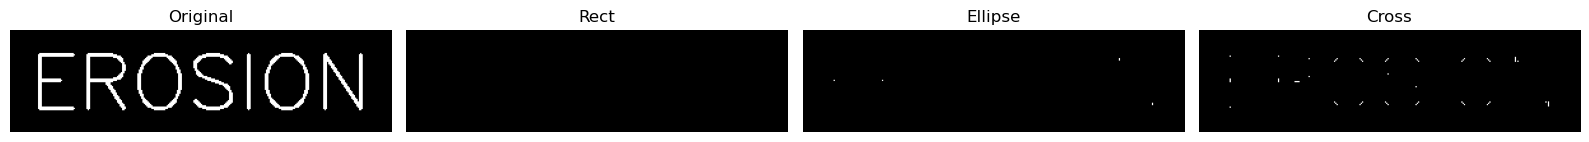

In [21]:
# Create a test image with text
test_text = create_clean_text_image("EROSION", font_size=2, image_size=(80, 300))

# Apply erosion with different kernels
eroded_rect = apply_erosion(test_text, kernel_rect)
eroded_ellipse = apply_erosion(test_text, kernel_ellipse)
eroded_cross = apply_erosion(test_text, kernel_cross)

# Validation
assert eroded_rect is not None, "apply_erosion should return an image"
assert eroded_rect.shape == test_text.shape, "Output shape should match input"
assert eroded_rect.sum() < test_text.sum(), "Erosion should reduce white pixels"

print("Question 2 validation passed!")
print(f"Original white pixels: {test_text.sum() // 255}")
print(f"After erosion (rect): {eroded_rect.sum() // 255}")

# Visualize
compare_morphological_ops(
    test_text,
    {'Rect': eroded_rect, 'Ellipse': eroded_ellipse, 'Cross': eroded_cross}
)

#### Validation Checkpoint 2

In [22]:
# Validation for Question 2
test_img = np.ones((50, 50), dtype=np.uint8) * 255
test_img[20:30, 20:30] = 0  # Black square in center
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
eroded = apply_erosion(test_img, test_kernel)

assert eroded is not None, "apply_erosion returned None"
assert eroded.shape == test_img.shape, "Output shape mismatch"
# Black region should expand after erosion (white shrinks)
assert eroded[19, 25] == 0, "Erosion should expand black region"

print("\u2713 Question 2 validation passed!")
print(f"  Original white pixels: {(test_img == 255).sum()}")
print(f"  After erosion: {(eroded == 255).sum()}")

✓ Question 2 validation passed!
  Original white pixels: 2400
  After erosion: 2356


### Exercise 3: Dilation

Implement dilation: look for the function in Opencv that applies dilation to a binary image and complete the following `apply_dilation` function. Then, use the provided code to create a test image with text and apply dilation with different kernels.

**Dilation** expands white (foreground) regions by adding pixels at boundaries. A pixel becomes white if ANY pixel under the structuring element is white.

In [23]:
def apply_dilation(image, kernel, iterations=1):
    """
    Apply dilation to a binary image.
    
    Args:
        image: Binary input image
        kernel: Structuring element
        iterations: Number of times to apply dilation
    
    Returns:
        np.array: Dilated image
    """

    # YOUR CODE HERE
    # Apply dilation using OpenCV function
    # This expands white regions
    return cv2.dilate(image, kernel, iterations=iterations)

Question 3 validation passed!
Original white pixels: 2098
After dilation (rect): 5396


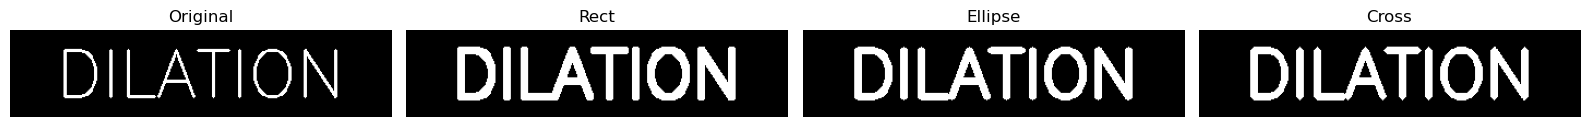

In [24]:
# Apply dilation with different kernels
test_text = create_clean_text_image("DILATION", font_size=2, image_size=(80, 350))

dilated_rect = apply_dilation(test_text, kernel_rect)
dilated_ellipse = apply_dilation(test_text, kernel_ellipse)
dilated_cross = apply_dilation(test_text, kernel_cross)

# Validation
assert dilated_rect is not None, "apply_dilation should return an image"
assert dilated_rect.shape == test_text.shape, "Output shape should match input"
assert dilated_rect.sum() > test_text.sum(), "Dilation should increase white pixels"

print("Question 3 validation passed!")
print(f"Original white pixels: {test_text.sum() // 255}")
print(f"After dilation (rect): {dilated_rect.sum() // 255}")

# Visualize
compare_morphological_ops(
    test_text,
    {'Rect': dilated_rect, 'Ellipse': dilated_ellipse, 'Cross': dilated_cross}
)

#### Validation Checkpoint 3

In [25]:
# Validation for Question 3
test_img = np.zeros((50, 50), dtype=np.uint8)
test_img[20:30, 20:30] = 255  # White square in center
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
dilated = apply_dilation(test_img, test_kernel)

assert dilated is not None, "apply_dilation returned None"
assert dilated.shape == test_img.shape, "Output shape mismatch"
# White region should expand after dilation
assert dilated[19, 25] == 255, "Dilation should expand white region"

print("\u2713 Question 3 validation passed!")
print(f"  Original white pixels: {(test_img == 255).sum()}")
print(f"  After dilation: {(dilated == 255).sum()}")

✓ Question 3 validation passed!
  Original white pixels: 100
  After dilation: 144


### Exercise 4: Opening and Closing

Implement opening and closing: look for the functions in Opencv that apply opening and closing to a binary image and complete the following `apply_opening` and `apply_closing` functions.
Then, use the provided code to create test images with text. This time we will also add salt or pepper noise: https://en.wikipedia.org/wiki/Salt-and-pepper_noise


- **Opening** = Erosion followed by Dilation (removes small white noise)
- **Closing** = Dilation followed by Erosion (fills small black holes)

**Hint**: You can use `cv2.morphologyEx()` with `cv2.MORPH_OPEN` or `cv2.MORPH_CLOSE`

In [26]:
def apply_opening(image, kernel):
    """
    Apply morphological opening (erosion then dilation).
    Removes small white noise from binary images.
    
    Args:
        image: Binary input image
        kernel: Structuring element
    
    Returns:
        np.array: Opened image
    """

    # YOUR CODE HERE
    # Opening: Erosion followed by Dilation
    # Useful for removing small white noise (salt noise)
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)


def apply_closing(image, kernel):
    """
    Apply morphological closing (dilation then erosion).
    Fills small black holes in binary images.
    
    Args:
        image: Binary input image
        kernel: Structuring element
    
    Returns:
        np.array: Closed image
    """

    # YOUR CODE HERE
    # Closing: Dilation followed by Erosion
    # Useful for filling small black holes (pepper noise) or closing gaps
    return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

Question 4 validation passed!


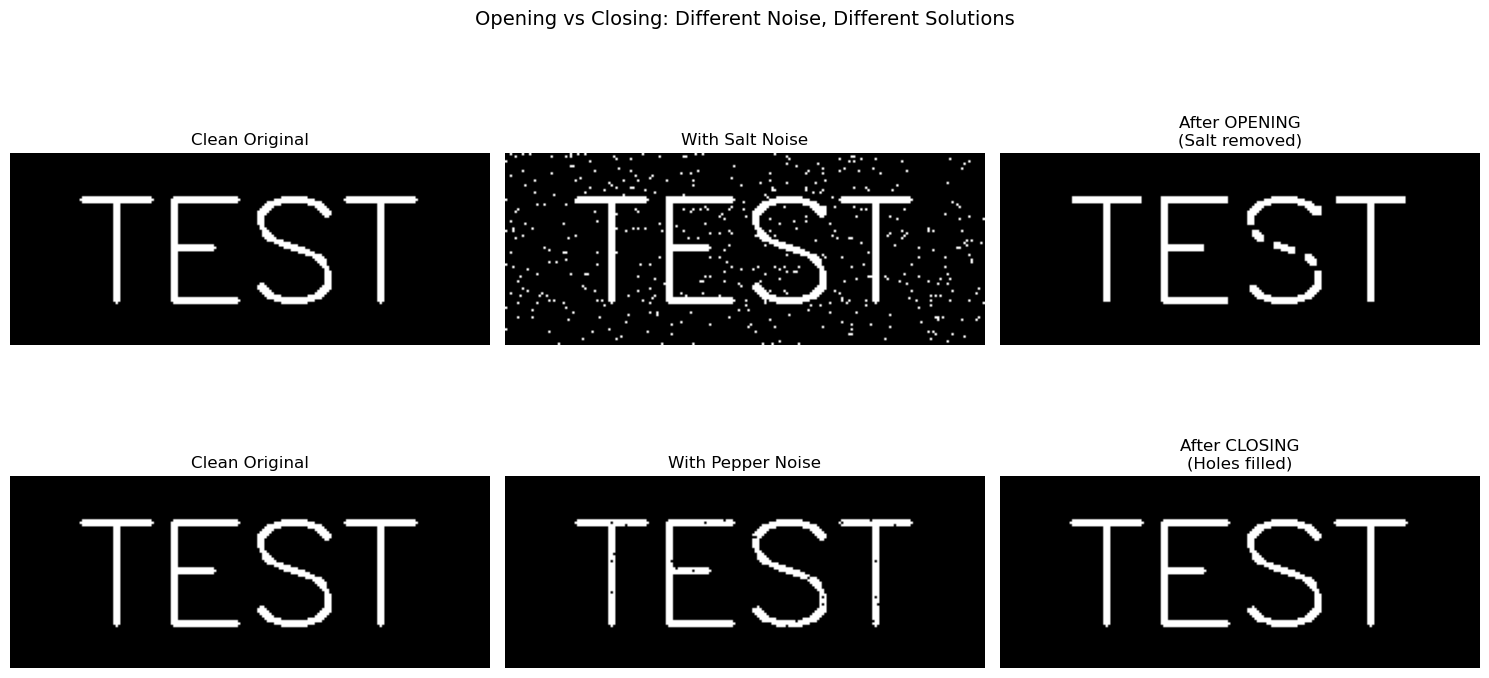

In [27]:
# Create images with different noise types
clean_text = create_clean_text_image("TEST", font_size=2, image_size=(80, 200))
salt_noisy = add_salt_noise(clean_text, ratio=0.03)  # White noise in background
pepper_noisy = add_pepper_noise(clean_text, ratio=0.03)  # Black holes in text

kernel_3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Apply opening to remove salt noise
opened = apply_opening(salt_noisy, kernel_3)

# Apply closing to fill pepper holes
closed = apply_closing(pepper_noisy, kernel_3)

# Validation
assert opened is not None, "apply_opening should return an image"
assert closed is not None, "apply_closing should return an image"

# Opening should reduce white pixels (removes salt noise)
assert opened.sum() < salt_noisy.sum(), "Opening should remove salt noise"
# Closing should increase white pixels (fills pepper holes)
assert closed.sum() > pepper_noisy.sum(), "Closing should fill pepper holes"

print("Question 4 validation passed!")

# Visualize the effects
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(clean_text, cmap='gray')
axes[0, 0].set_title('Clean Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(salt_noisy, cmap='gray')
axes[0, 1].set_title('With Salt Noise')
axes[0, 1].axis('off')

axes[0, 2].imshow(opened, cmap='gray')
axes[0, 2].set_title('After OPENING\n(Salt removed)')
axes[0, 2].axis('off')

axes[1, 0].imshow(clean_text, cmap='gray')
axes[1, 0].set_title('Clean Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(pepper_noisy, cmap='gray')
axes[1, 1].set_title('With Pepper Noise')
axes[1, 1].axis('off')

axes[1, 2].imshow(closed, cmap='gray')
axes[1, 2].set_title('After CLOSING\n(Holes filled)')
axes[1, 2].axis('off')

plt.suptitle('Opening vs Closing: Different Noise, Different Solutions', fontsize=14)
plt.tight_layout()
plt.show()

#### Validation Checkpoint 4

In [28]:
# Validation for Question 4
test_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Test opening removes small white noise
test_open = np.zeros((50, 50), dtype=np.uint8)
test_open[25, 25] = 255  # Single white pixel (noise)
opened_test = apply_opening(test_open, test_kernel)
assert opened_test is not None, "apply_opening returned None"
assert opened_test[25, 25] == 0, "Opening should remove isolated white pixel"

# Test closing fills small black holes
test_close = np.ones((50, 50), dtype=np.uint8) * 255
test_close[25, 25] = 0  # Single black pixel (hole)
closed_test = apply_closing(test_close, test_kernel)
assert closed_test is not None, "apply_closing returned None"
assert closed_test[25, 25] == 255, "Closing should fill isolated black pixel"

print("\u2713 Question 4 validation passed!")
print("  Opening correctly removes small white noise")
print("  Closing correctly fills small black holes")

✓ Question 4 validation passed!
  Opening correctly removes small white noise
  Closing correctly fills small black holes


### Exercise 5 (0.20pts):
- Explain and visually show with your own examples what is the effect of using different kernel shapes and sizes.
- Implement a method to better visualize which areas of the image changed after applying these operations, other than having to compare two images simultaneously.



### Answer to Exercise 5

**1. Effect of Kernel Size:**
The size of the structuring element determines the "aggressiveness" or reach of the morphological operation.
* **Small Kernels (e.g., 3x3):** Affect only the immediate boundary of objects. In the example above, the 3x3 erosion simply thins the text strokes.
* **Large Kernels (e.g., 9x9):** Interact with a much larger neighborhood. In the example, the 9x9 erosion completely removes the text "SIZE" because the stroke width of the letters is thinner than the kernel width (9 pixels). For a pixel to survive erosion, the entire 9x9 area around it must be white, which never happens here.

**2. Effect of Kernel Shape:**
The shape of the structuring element dictates the geometry of the transformation. The kernel effectively acts as a "stamp" or "probe".
* **Rectangle Kernel:** Treats all neighbors within the box equally. When applying dilation to a small circular point using a rectangular kernel, the result becomes a square (blocky appearance).
* **Cross Kernel:** Only considers horizontal and vertical neighbors, ignoring diagonals. When dilating the same point with a cross kernel, the result takes the shape of a cross/plus sign. This shows that morphological operations tend to impose the shape of the kernel onto the objects in the image.

**3. Visualization Method:**
To better visualize changes, we implemented a difference map using `cv2.absdiff(original, processed)`.
* This creates an image where pixels are black (0) if they remained unchanged, and white/colored (>0) if they were flipped by the operation.
* By using a heatmap (e.g., `cmap='hot'`), we can instantly highlight exactly which boundary pixels were added (in dilation) or removed (in erosion), avoiding the difficulty of spotting subtle changes when comparing images side-by-side.

--- DEMO 1: Impact of Kernel SIZE ---


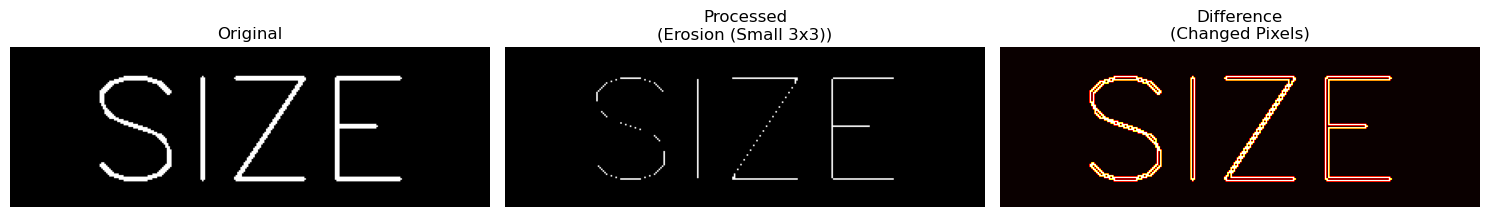

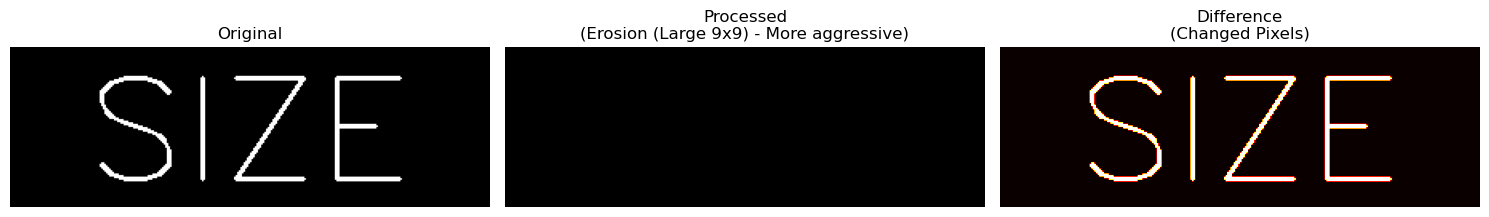


--- DEMO 2: Impact of Kernel SHAPE ---


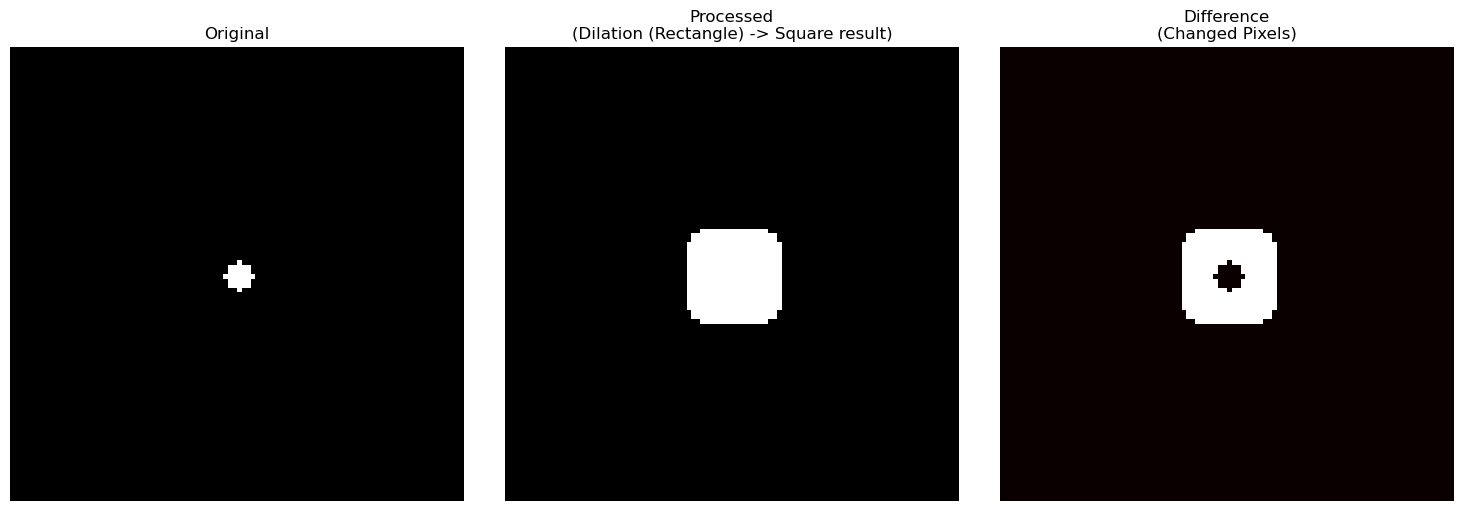

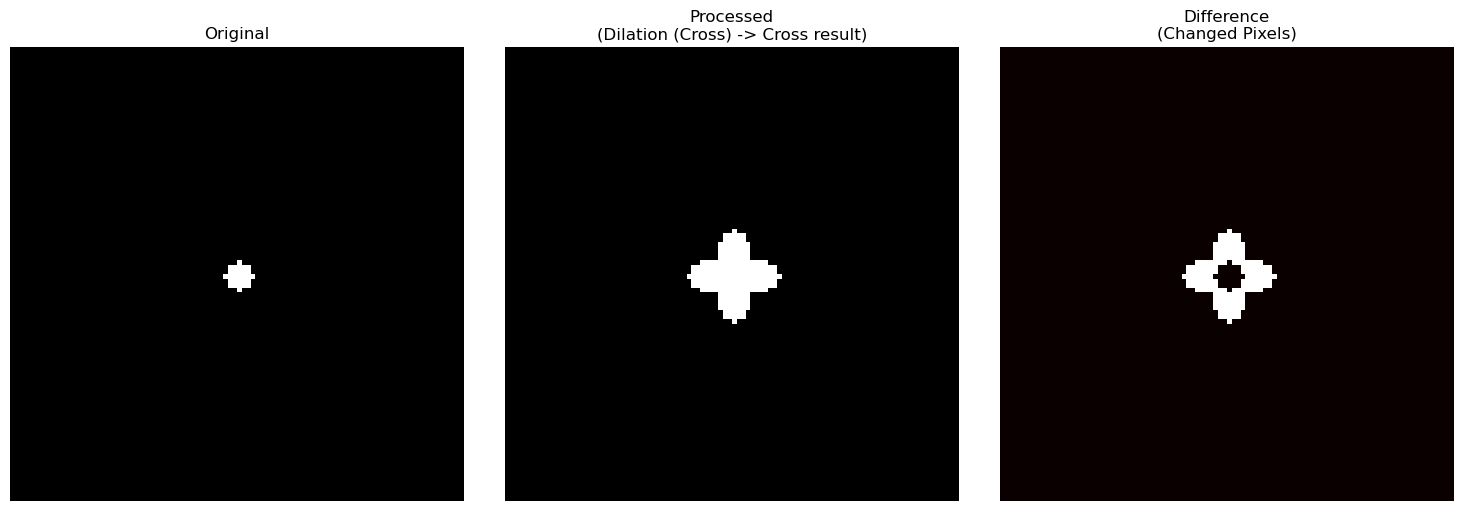

In [ ]:
def visualize_changes(original, processed, title="Morphological Operation"):
    """
    Visualizes the original image, the processed image, and the difference between them.
    This helps to clearly see which pixels were added (dilation) or removed (erosion).
    """
    # Compute absolute difference between images
    # Pixels that are equal become 0 (black), changed pixels become >0 (white)
    difference = cv2.absdiff(original, processed)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot Original
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Plot Processed
    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title(f'Processed\n({title})')
    axes[1].axis('off')
    
    # Plot Difference
    axes[2].imshow(difference, cmap='hot') # 'hot' colormap to highlight changes
    axes[2].set_title('Difference\n(Changed Pixels)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- DEMO 1: Effect of Kernel SIZE ---
print("--- DEMO 1: Impact of Kernel SIZE ---")
# Create a simple test image
test_img = create_clean_text_image("SIZE", font_size=3, image_size=(100, 300))

# Small kernel (3x3) vs Large kernel (9x9)
kernel_small = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kernel_large = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

# Apply Erosion
eroded_small = apply_erosion(test_img, kernel_small)
eroded_large = apply_erosion(test_img, kernel_large)

visualize_changes(test_img, eroded_small, "Erosion (Small 3x3)")
visualize_changes(test_img, eroded_large, "Erosion (Large 9x9) - More aggressive")


# --- DEMO 2: Effect of Kernel SHAPE ---
print("\n--- DEMO 2: Impact of Kernel SHAPE ---")
# Create a test image with a circle or simple shape to see deformation
shape_img = np.zeros((100, 100), dtype=np.uint8)
cv2.circle(shape_img, (50, 50), 3, 255, -1) # Small dot in center

# Rect vs Cross Dilation
# We use a large size to exaggerate the shape effect
kernel_rect_15 = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
kernel_cross_15 = cv2.getStructuringElement(cv2.MORPH_CROSS, (15, 15))

dilated_rect = apply_dilation(shape_img, kernel_rect_15)
dilated_cross = apply_dilation(shape_img, kernel_cross_15)

visualize_changes(shape_img, dilated_rect, "Dilation (Rectangle) -> Square result")
visualize_changes(shape_img, dilated_cross, "Dilation (Cross) -> Cross result")

---

## OCR with Morphological Preprocessing

**OCR (Optical Character Recognition)** is a technology that converts images containing text into machine-readable text. When you scan a document or take a photo of a sign, OCR algorithms analyze the image to identify and extract the text characters.

**How OCR works (simplified):**
1. **Preprocessing** - Clean up the image (binarization, noise removal)
2. **Character segmentation** - Identify individual characters
3. **Feature extraction** - Analyze character shapes and patterns
4. **Classification** - Match features to known characters using trained models

**Why image quality matters:**
OCR models are typically trained on clean, high-contrast text. When images are degraded by noise, blur, or poor lighting, the extracted features become unreliable and recognition accuracy drops significantly.

**The morphology connection:**
Since OCR works on binary images (black text on white background), morphological operations are ideal for preprocessing since, as we have already seen in this lab, they can:

1. **Remove noise** that confuses character recognition.
2. **Repair broken strokes** that split characters.
3. **Separate touching characters** that merge incorrectly.


### Real-World Data: SVHN Dataset

Instead of synthetic text, we'll use the **SVHN (Street View House Numbers)** dataset - real photographs of house number digits captured from Google Street View. This provides:

- Real-world lighting variations
- Natural image noise
- Authentic digit appearances
- Known ground truth labels for validation

Next, we will visualize a few examples (first row) and their binarized version (second row):

Loaded 5 SVHN images
Labels: [2, 1, 3, 0, 2]


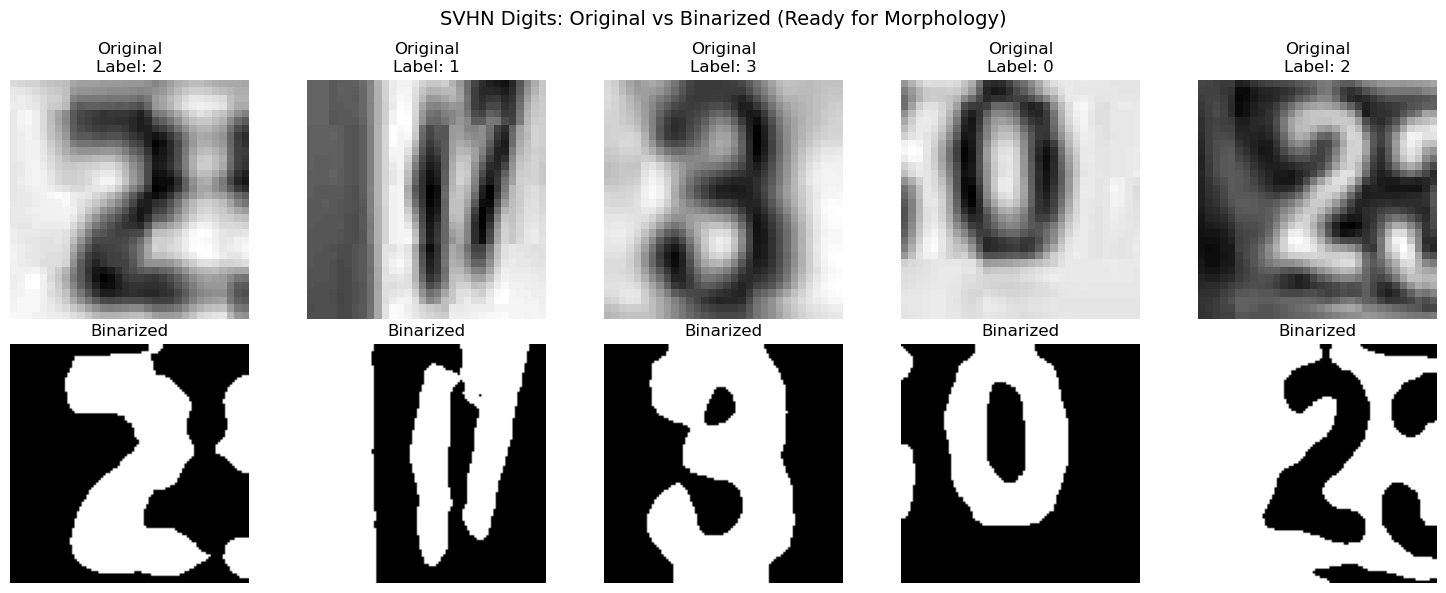

In [30]:
# Load SVHN dataset - real street number digits
svhn_images, svhn_labels = load_svhn_cropped(svhn_path, n_samples=5, seed=42)

print(f"Loaded {len(svhn_images)} SVHN images")
print(f"Labels: {svhn_labels}")

# Display original SVHN images
#visualize_svhn_samples(svhn_images, svhn_labels, title='SVHN Dataset: Real Street Number Digits')

# Prepare for morphological operations (resize and binarize)
binary_digits = [prepare_svhn_for_morphology(img, target_size=(100, 100)) for img in svhn_images]

# Show binarized versions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(svhn_images[i], cmap='gray')
    axes[0, i].set_title(f'Original\nLabel: {svhn_labels[i]}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(binary_digits[i], cmap='gray')
    axes[1, i].set_title('Binarized')
    axes[1, i].axis('off')

plt.suptitle('SVHN Digits: Original vs Binarized (Ready for Morphology)', fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 6 (0.5 pts): OCR Preprocessing Pipeline

In this part of the lab we will:
1. Apply synthetic degradation (salt/pepper noise; broken strokes; touching characters) to the SVHN digits and then,
2. Apply the most suitable morphological operations to restore them. The goal is to restore the degraded digit so OCR can recognize it.

First, think about the correct matching between the **degradation type** and the **correct morphological fix** and complete the following table:

| Degradation | Morphological Fix |
|-------------|-------------------|
| Salt noise (white spots in background) | **Opening** (Erosion -> Dilation) |
| Pepper noise (black holes in text) | **Closing** (Dilation -> Erosion) |
| Broken strokes (thin/disconnected) | **Dilation** (Expands foreground to connect parts) |
| Touching characters | **Erosion** (Shrinks foreground to separate objects) |

**HINT:** Would it be possible to create broken strokes and touching parameters using the morphological operations seen before?

Then, complete the following code to apply the most suitable morphological operation to restore each of the suggested image degradation types:

In [ ]:
def preprocess_for_ocr(image, degradation_type='combined'):
    """
    Apply morphological preprocessing to improve OCR results.
    
    Args:
        image: Binary input image (white text on black background)
        degradation_type: One of 'salt', 'pepper', 'eroded', 'combined'
    
    Returns:
        np.array: Preprocessed binary image
    """
    # Define a standard 3x3 kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    result = image  # Default: return original if unknown type
    
    if degradation_type == 'salt':
        # Salt noise = white spots in background
        # Fix with: OPENING (removes small white objects)
        result = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        
    elif degradation_type == 'pepper':
        # Pepper noise = black holes in text
        # Fix with: CLOSING (fills small black holes)
        result = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        
    elif degradation_type == 'eroded':
        # Eroded strokes = thin/broken text
        # Fix with: DILATION (thickens strokes and reconnects broken parts)
        result = cv2.dilate(image, kernel, iterations=1)
        
    elif degradation_type == 'combined':
        solid_digit = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        result = cv2.morphologyEx(solid_digit, cv2.MORPH_OPEN, kernel)
    
    return result

Now try the full pipeline **with several examples** (i.e. different degraded versions, different samples from the dataset, etc.) and explain what do you observe. Will the restoration always work?

### Observations on Pipeline Robustness

**Will the restoration always work?**
**No**, the restoration will not always work. Morphological operations are based on fixed geometric rules, not semantic understanding of the digits.

**Key Observations and Limitations:**

1.  **Kernel Size vs. Degradation Magnitude:**
    * The structuring element (kernel) acts as a bridge. If a "break" or gap in a digit's stroke is **larger** than the kernel size (e.g., a 5-pixel gap vs. a 3-pixel kernel), the morphological **Closing** or **Dilation** will fail to bridge the connection, and the digit will remain broken.

2.  **Risk of Topological Changes (Shape Distortion):**
    * Operations like **Dilation** or **Closing** add pixels. While this fixes broken strokes, it can also unintentionally close valid "loops" or curves in digits.
    * *Example:* A heavy closing operation might connect the open tails of a **'3'** or **'5'**, making them look like an **'8'** or **'6'** respectively. This confuses the OCR more than the original degradation.

3.  **Noise Density:**
    * If **Salt noise** is very dense, the white noise pixels might clump together to form a shape larger than the kernel used for **Opening**. The algorithm will interpret this noise clump as a valid object (foreground) and preserve it, leading to OCR errors.

**Conclusion:**
The pipeline works best when the kernel size is tuned specifically to the stroke width of the characters and the expected scale of the noise. There is no single "magic" kernel that fixes all levels of degradation without side effects.

Testing with SVHN digit: 2


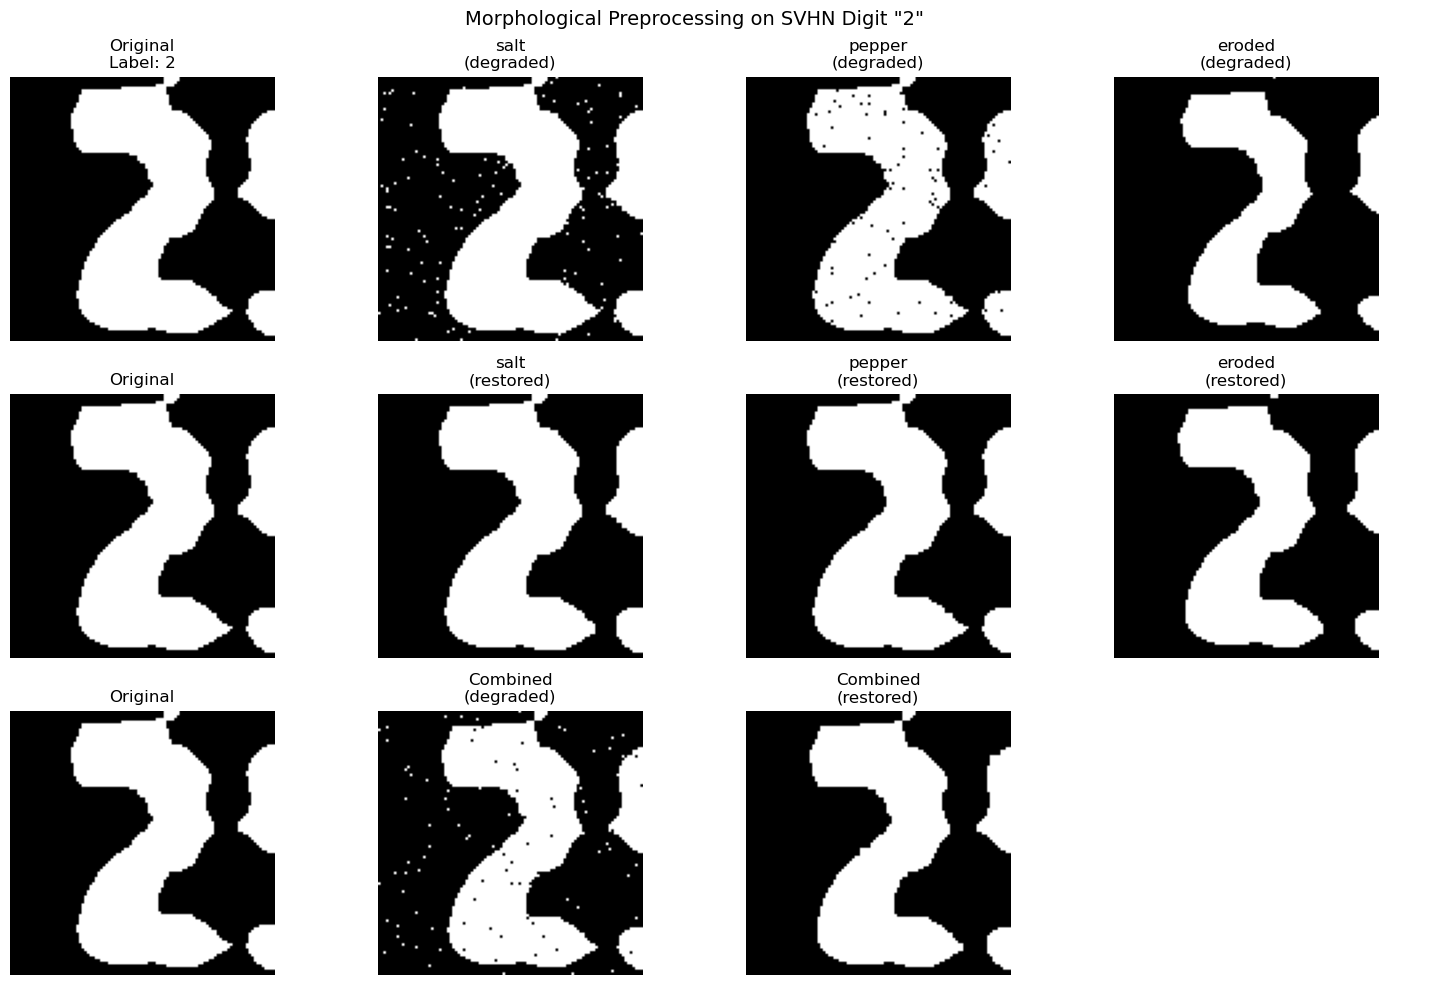

In [32]:
# Test preprocessing on SVHN digits with synthetic degradation
# Use the first binarized digit as our test image
test_digit = binary_digits[0]
ground_truth_label = str(svhn_labels[0])

print(f"Testing with SVHN digit: {ground_truth_label}")

#Create degraded versions
degraded = {
    'salt': add_salt_noise(test_digit, 0.02),
    'pepper': add_pepper_noise(test_digit, 0.02),
    'eroded': apply_stroke_erosion(test_digit, 3, 2),
    'combined': add_salt_noise(add_pepper_noise(apply_stroke_erosion(test_digit, 2, 1), 0.01), 0.01)
}


# Apply preprocessing
restored = {}
for dtype, img in degraded.items():
    restored[dtype] = preprocess_for_ocr(img, dtype)

# # Validation
# for dtype in degraded:
#     assert restored[dtype] is not None, f"Preprocessing for {dtype} should return an image"
#
# print("Question 5 validation passed!")

# Visualize before/after
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

# Row 0: Original and degraded
axes[0, 0].imshow(test_digit, cmap='gray')
axes[0, 0].set_title(f'Original\nLabel: {ground_truth_label}')
axes[0, 0].axis('off')

for idx, dtype in enumerate(list(degraded.keys())[:3], start=1):
    axes[0, idx].imshow(degraded[dtype], cmap='gray')
    axes[0, idx].set_title(f'{dtype}\n(degraded)')
    axes[0, idx].axis('off')

# Row 1: Restored versions
axes[1, 0].imshow(test_digit, cmap='gray')
axes[1, 0].set_title('Original')
axes[1, 0].axis('off')

for idx, dtype in enumerate(list(restored.keys())[:3], start=1):
    axes[1, idx].imshow(restored[dtype], cmap='gray')
    axes[1, idx].set_title(f'{dtype}\n(restored)')
    axes[1, idx].axis('off')

# Row 2: Combined case
axes[2, 0].imshow(test_digit, cmap='gray')
axes[2, 0].set_title('Original')
axes[2, 0].axis('off')

axes[2, 1].imshow(degraded['combined'], cmap='gray')
axes[2, 1].set_title('Combined\n(degraded)')
axes[2, 1].axis('off')

axes[2, 2].imshow(restored['combined'], cmap='gray')
axes[2, 2].set_title('Combined\n(restored)')
axes[2, 2].axis('off')

axes[2, 3].axis('off')

plt.suptitle(f'Morphological Preprocessing on SVHN Digit "{ground_truth_label}"', fontsize=14)
plt.tight_layout()
plt.show()

**OCR Testing with EasyOCR:**
Now let's use EasyOCR (https://github.com/JaidedAI/EasyOCR) to see if preprocessing actually improves text recognition.

First, initialize EasyOCR:

In [33]:
# Install the EasyOCR library inside the notebook environment
# !pip install easyocr

In [34]:
# Initialize EasyOCR (downloads models on first run)
#import easyocr
try:
    import easyocr
    reader = easyocr.Reader(['en'], gpu=False, verbose=False)
    OCR_AVAILABLE = True
    print("EasyOCR initialized successfully!")
except ImportError:
    print("EasyOCR not installed. Run: pip install easyocr")
    OCR_AVAILABLE = False

def extract_text(image):
    """
    Extract text from image using EasyOCR.
    
    Args:
        image: Grayscale or binary image
    
    Returns:
        str: Extracted text
    """
    if not OCR_AVAILABLE:
        return "[OCR not available]"
    
    # EasyOCR expects images in a certain format
    if len(image.shape) == 2:
        # Already grayscale
        img = image
    else:
        img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    results = reader.readtext(img)
    text = ' '.join([r[1] for r in results])
    return text.strip()

EasyOCR initialized successfully!


Now, test it on the previously computed degraded and restored digits. The following code will only highlight cases where morphology had an effect (positive or negative) in recognizing the digits.
Go back and generate different degraded + restored images and then run the following code to see the impact of these operations in the identification of the true digits. Briefly summarize what do you observe. Is there a degradation that is harder / easier to recover?

### Observations on OCR Performance

**Summary of Observations:**
Morphological preprocessing generally improves the OCR accuracy significantly compared to the raw degraded images. By removing noise and reconnecting broken strokes, the text becomes much clearer for the recognition engine.

**Which degradation is easier/harder?**

* **Easier to Recover:** **Salt** and **Pepper** noise.
    * These are "easier" because the noise consists of isolated pixels (small artifacts) that are distinct from the character shapes. Morphological **Opening** and **Closing** are extremely effective filters for this specific type of noise, allowing us to clean the image almost perfectly without altering the digit's structure too much.

* **Harder to Recover:** **Eroded** (Broken Strokes) and **Combined**.
    * **Eroded:** This is harder because fixing it requires **Dilation**. While dilation reconnects broken lines, it also makes the characters thicker. If the digits are close to each other, dilation can cause them to touch or merge into a single blob, causing the OCR to misinterpret two digits as one (e.g., reading "1 0" as "8" or "B").
    * **Combined:** This is the **hardest** scenario. It requires a delicate balance: if we try to remove noise first, we might accidentally erase the faint broken strokes. If we try to thicken the strokes first, we might amplify the noise. Finding the correct order of operations (e.g., Closing then Opening) is critical and more prone to errors than single-type degradations.

In [35]:
# Test OCR on degraded vs restored SVHN digits
# Only show cases where morphology had an EFFECT (positive or negative)
if OCR_AVAILABLE:
    print(f"Ground truth label: '{ground_truth_label}'")
    print("-" * 50)
    print("Showing cases where morphology CHANGED the OCR result:")
    print()
    
    effect_count = 0
    for dtype in degraded.keys():
        text_degraded = extract_text(degraded[dtype])
        text_restored = extract_text(restored[dtype])
        
        # Only show if morphology changed the result
        if text_degraded != text_restored:
            effect_count += 1
            degraded_correct = text_degraded == ground_truth_label
            restored_correct = text_restored == ground_truth_label
            
            print(f"{dtype.upper()} degradation:")
            print(f"  Before: '{text_degraded}' {'[correct]' if degraded_correct else '[incorrect]'}")
            print(f"  After:  '{text_restored}' {'[correct]' if restored_correct else '[incorrect]'}")
            
            if restored_correct and not degraded_correct:
                print(f"  -> IMPROVED! Morphology fixed the recognition")
            elif degraded_correct and not restored_correct:
                print(f"  -> WORSE! Morphology damaged the digit")
            else:
                print(f"  -> Changed (both incorrect)")
            print()
    
    if effect_count == 0:
        print("No changes detected - morphology had no effect on any case")
    else:
        print(f"Morphology changed {effect_count}/{len(degraded)} cases")
else:
    print("Skipping OCR test - EasyOCR not installed")
    print("To enable OCR testing, run: pip install easyocr")

Ground truth label: '2'
--------------------------------------------------
Showing cases where morphology CHANGED the OCR result:

No changes detected - morphology had no effect on any case


### Exercise 7 (0.15 pts): Comprehensive Morphological Pipeline Evaluation

Now it's time to put your `preprocess_for_ocr` function to the test on a **larger dataset**. The `evaluate_morphological_pipeline` function will:

1. Load multiple SVHN digits
2. Apply various degradation types (salt, pepper, erosion, combined). **This is fixed now**.
3. Run your preprocessing pipeline. **Run your `preprocess_for_ocr` function and further modify if needed.**
4. Use OCR to measure digit recognition accuracy before and after your preprocessing

Your goal is to achieve **overall improvement > 0%**  (the higher, the better), showing that your morphological pipeline genuinely helps OCR recognize degraded digits better.

**Challenge levels:**
- Beginner: Any positive improvement
- Intermediate: > 5% improvement
- Advanced: > 10% improvement

Evaluating your morphological pipeline on SVHN digits...
This will test your preprocess_for_ocr function against real OCR.
Examples shown are cases where morphology CHANGED the OCR result.

Loaded 15 SVHN digits for evaluation
Testing degradation types: salt, pepper, eroded, combined
------------------------------------------------------------

MORPHOLOGICAL PIPELINE EVALUATION RESULTS

Degradation  | Before     | After      | Change    
--------------------------------------------------
salt         |     40.0% |     46.7% | +    6.7%
pepper       |     33.3% |     40.0% | +    6.7%
eroded       |     33.3% |     40.0% | +    6.7%
combined     |     40.0% |     46.7% | +    6.7%
--------------------------------------------------
OVERALL      |     36.7% |     43.3% | +    6.7%

Pipeline shows significant improvement!


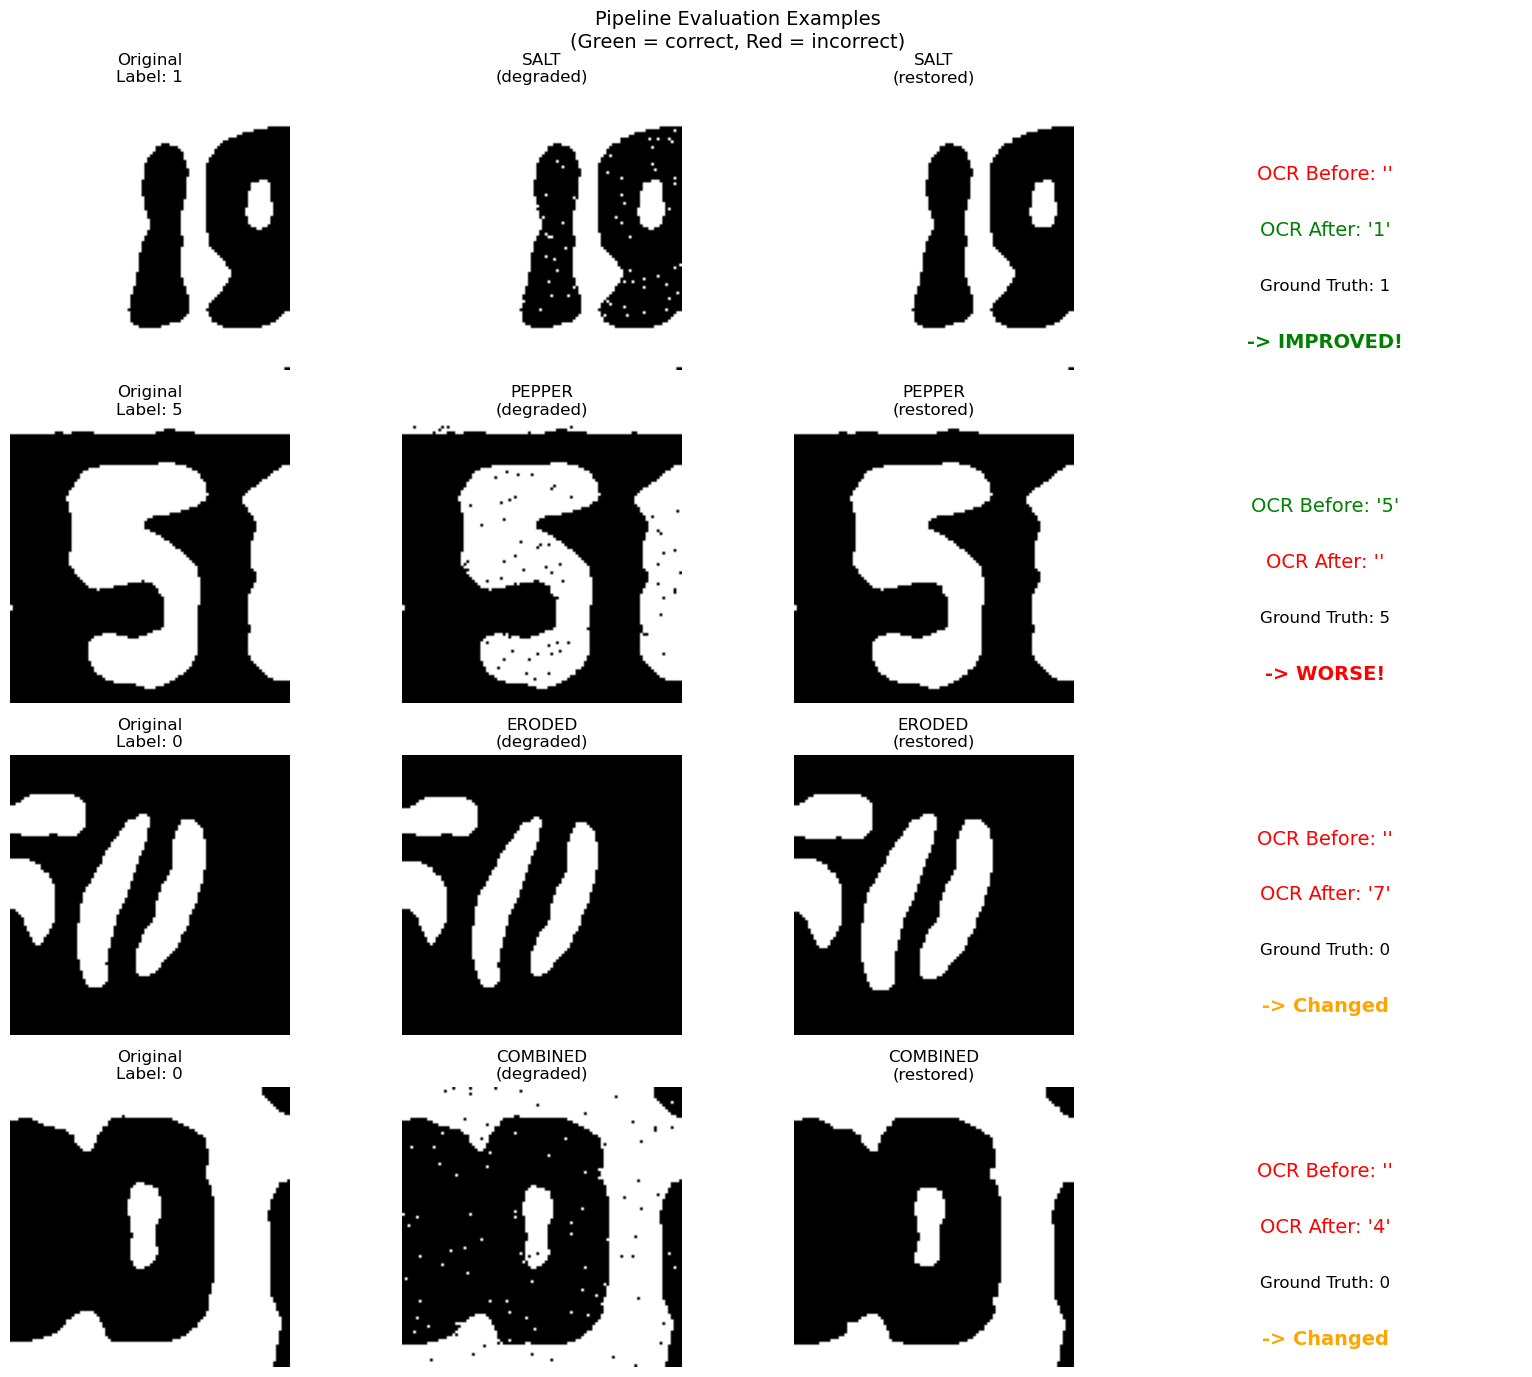


GOOD! Your pipeline shows solid improvement (>5%).


In [36]:
# Evaluate your preprocess_for_ocr function on the full SVHN test set
# This will take about 30-60 seconds depending on your machine

if OCR_AVAILABLE:
    print("Evaluating your morphological pipeline on SVHN digits...")
    print("This will test your preprocess_for_ocr function against real OCR.")
    print("Examples shown are cases where morphology CHANGED the OCR result.")
    print()
    
    # Run the evaluation
    results = evaluate_morphological_pipeline(
        pipeline_func=preprocess_for_ocr,
        svhn_path=svhn_path,
        n_samples=15,
        degradation_ratio=0.02,
        verbose=True,
        show_examples=True,
        show_only_changed=True  # Only show examples where morphology had an effect
    )
    
    if results is not None:
        improvement = results['overall_improvement']
        
        print("\n" + "=" * 60)
        if improvement > 10:
            print("EXCELLENT! Your pipeline shows significant improvement (>10%)!")
        elif improvement > 5:
            print("GOOD! Your pipeline shows solid improvement (>5%).")
        elif improvement > 0:
            print("Your pipeline shows some improvement.")
        else:
            print("Your pipeline needs work - accuracy decreased or stayed the same.")
        print("=" * 60)
else:
    print("OCR not available. Install EasyOCR to run this evaluation:")
    print("  pip install easyocr")

---
## Pipeline for real medical image segmentation

In this part of the lab we are asked to compute the area of the gray matter from a 2D MRI scan. We will do it in 3 steps:
1. Apply the region growing algorithm to segment different areas of the brain. We will try to at least separate: gray matter, left and right brain ventricles, and skull.
2. Apply morphological operation to clean the segmentation (in this case, with several labels, one for each region).
3. Use the pixel size to compute the area of the gray matter. This (it would be better to compute the volume) may be indicative of cognitive impairment.


**Region growing** is a seed-based segmentation algorithm that:
1. Starts from user-defined seed points.
2. Iteratively adds neighboring pixels that are "similar" to the region.
3. Stops when no more similar pixels can be added.

The similarity criterion typically compares pixel intensity to the region mean:
$$C(v, i) = |I[v] - \mu_i| \leq \tau$$

Where:
- $I[v]$ is the pixel intensity at position $v$
- $\mu_i$ is the mean intensity of region $i$
- $\tau$ is the similarity threshold

We first load the data:

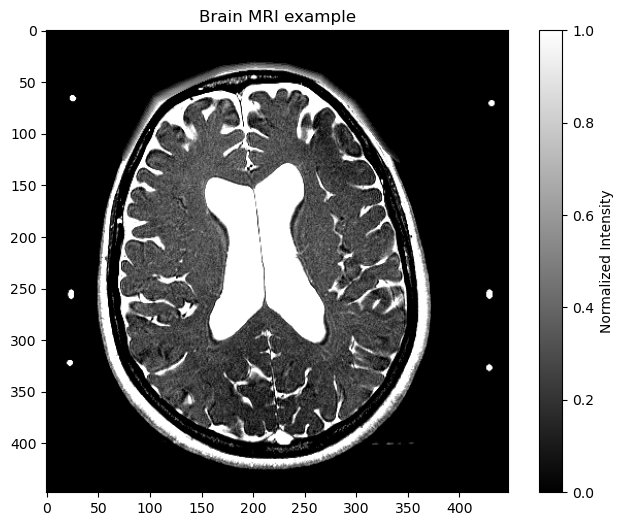

In [37]:
brain_mri = cv2.imread('data/brain_MRI_GM2.png', cv2.IMREAD_GRAYSCALE)     # original image for reference

if brain_mri is None:
    print(f"Could not load image, check path")
else:
    mri_normalized = brain_mri.astype(np.float64) / 255.0
    
    # Visualize
    plt.figure(figsize=(8, 6))
    plt.imshow(mri_normalized, cmap='gray')
    plt.title(f'Brain MRI example')
    plt.colorbar(label='Normalized Intensity')
    plt.show()

### Exercise 8 (0.15 pts): Region Growing Segmentation

Apply region growing segmentation to the MRI slice. The final objective is to calculate the area of the gray matter, so we need to pay special attention to this area. At this point we will try to at least separate:
- gray matter
- the 2 brain ventricles (gray structures in the center of the image)
- the skull (outer white contour)

**Task**: using the following code **define appropriate seed points** for different brain structures and run the segmentation. **Tune the parameters tau and max_iterations** to get approximate correct segmentations.

When the algorithm finishes you will be able to visualize the iterative region growing process.

**Hints**:
- Coordinates are (row, col) - row is Y (vertical), col is X (horizontal)
- Click on the image above to identify approximate coordinates
- Start with a single seed, then try multiple seeds (one per region)

Iteration 0: 7/200704 pixels (0.0%)
Iteration 1000: 1137/200704 pixels (0.6%)
Iteration 2000: 2179/200704 pixels (1.1%)
Iteration 3000: 3209/200704 pixels (1.6%)
Iteration 4000: 4238/200704 pixels (2.1%)
Iteration 5000: 5259/200704 pixels (2.6%)
Iteration 6000: 6271/200704 pixels (3.1%)
Iteration 7000: 7289/200704 pixels (3.6%)
Iteration 8000: 8303/200704 pixels (4.1%)
Iteration 9000: 9317/200704 pixels (4.6%)
Iteration 10000: 10323/200704 pixels (5.1%)
Iteration 11000: 11333/200704 pixels (5.6%)
Iteration 12000: 12319/200704 pixels (6.1%)
Iteration 13000: 13314/200704 pixels (6.6%)
Iteration 14000: 14316/200704 pixels (7.1%)
Iteration 15000: 15331/200704 pixels (7.6%)
Iteration 16000: 16337/200704 pixels (8.1%)
Iteration 17000: 17348/200704 pixels (8.6%)
Iteration 18000: 18359/200704 pixels (9.1%)
Iteration 19000: 19363/200704 pixels (9.6%)
Iteration 20000: 20371/200704 pixels (10.1%)
Iteration 21000: 21378/200704 pixels (10.7%)
Iteration 22000: 22375/200704 pixels (11.1%)
Iteration 2

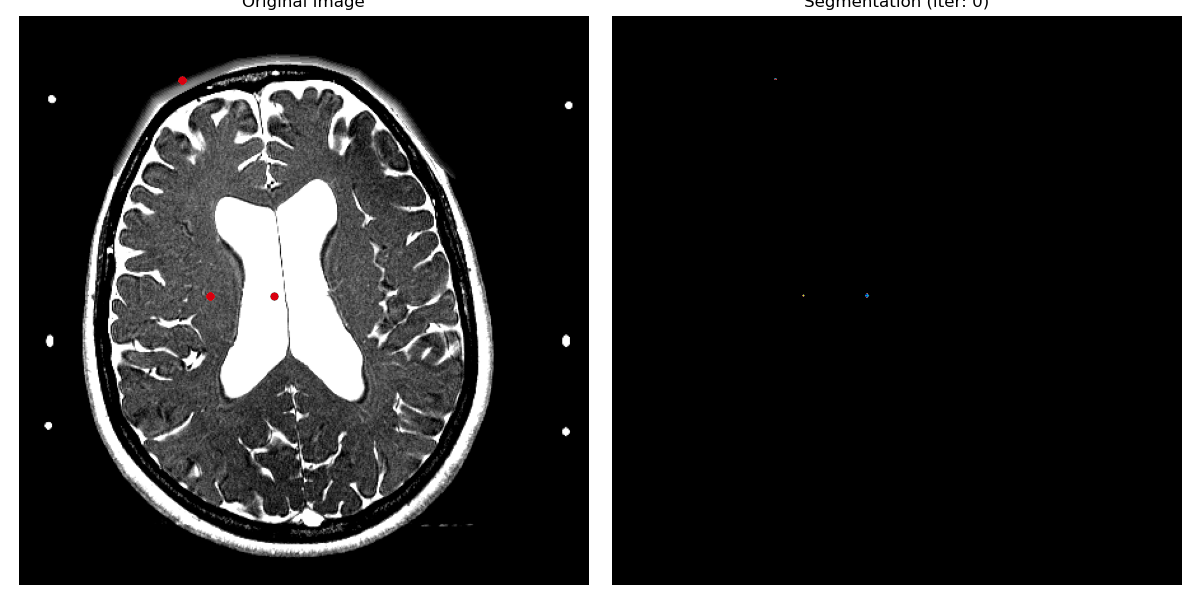

In [38]:
# Define seed points for different structures
# Coordinates are (row, col) - (Y, X)
seed_points = (
    (220, 200),  # Seed 0: Ventricles (dark butterfly shape in center)
    (220, 150),   # Seed 1: Gray Matter (cortical fold)
    (50, 128)    # Seed 2: Skull/Scalp (outer bright ring)
)

# TAU: Similarity threshold. 
# 0.08 - 0.12 is usually a good range for this MRI.
tau = 0.11

# Create the criterion function
criterion = make_similarity_criterion(mri_normalized, tau=tau)

# Run region growing
# Note: This might take a few seconds to generate the GIF
segmentation = visualize_region_growing(
    mri_normalized,
    seed_points,
    criterion,
    frame_step=1000,
    output_path="region_growing_mri.gif",
    fps=10,
    max_iterations=180000,
    verbose=True
)

#### Validation Checkpoint 8

In [39]:
# Validation for Question 8
assert segmentation is not None, "Region growing returned None"
assert segmentation.shape == mri_normalized.shape, "Segmentation shape mismatch"
unique_regions = np.unique(segmentation[segmentation >= 0])
assert len(unique_regions) >= 1, "No regions segmented"

print("\u2713 Question 8 validation passed!")
print(f"  Segmentation shape: {segmentation.shape}")
print(f"  Number of regions: {len(unique_regions)}")
print(f"  Region IDs: {list(unique_regions)}")

✓ Question 8 validation passed!
  Segmentation shape: (448, 448)
  Number of regions: 3
  Region IDs: [0, 1, 2]


### Exercise 9 (0.20 pts): segmentation post-processing and area calculation.

Hopefully you would have computed an approximate segmentation of the different structures. With respect to the gray matter, due to its own intensity heterogeneity (which has been deliberately exaggerated in the image) the result is not optimal (with many small black dots). We will now **apply morphological operations to clean the masks** obtained before.
Think about the most appropriate operation or set of operations, bearing in mind that our aim is to eliminate the small black dots while keeping the brain sulci (folds) unmodified.

**Morphological Operation Selection:**
To clean the segmentation of the gray matter, we observe **small black holes** inside the region of interest (pepper noise). 
* The most appropriate operation is **Closing** (Dilation followed by Erosion).
* **Why?** Closing fills small holes and gaps within the foreground object while maintaining the original size and general shape of the outer boundaries (the brain folds/sulci), which are critical for accurate anatomical measurement.

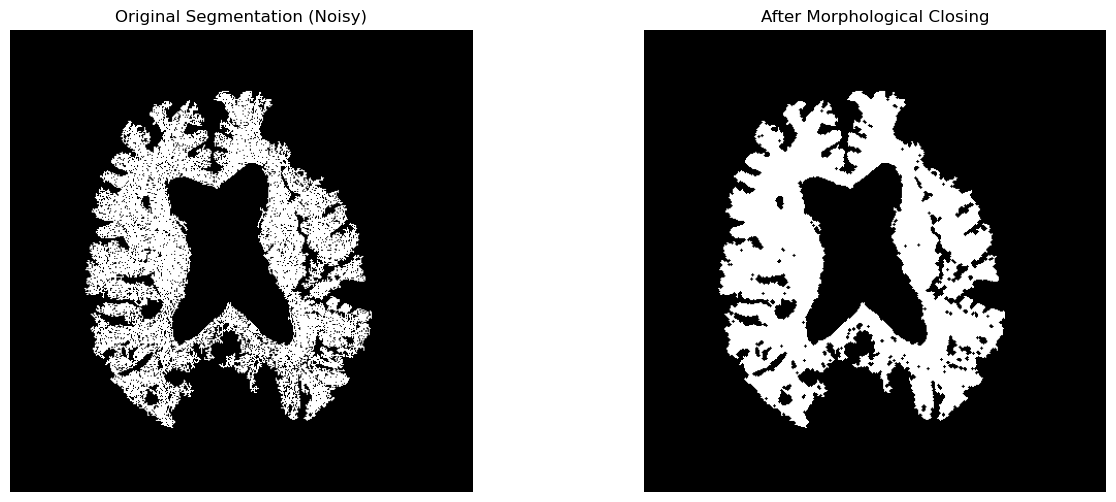

In [40]:
# 1. Select the label corresponding to Gray Matter
# Based on our seeds, Seed 1 (index 1) was placed on Gray Matter
target_label = 1
gm_mask = (segmentation == target_label).astype(np.uint8) * 255

## MORPHOLOGICAL OPERATIONS
# Use Closing to fill small holes inside the gray matter
kernel_mri = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
gm_post = cv2.morphologyEx(gm_mask, cv2.MORPH_CLOSE, kernel_mri)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(gm_mask, cmap='gray')
axes[0].set_title('Original Segmentation (Noisy)')
axes[0].axis('off')

axes[1].imshow(gm_post, cmap='gray')
axes[1].set_title('After Morphological Closing')
axes[1].axis('off')
plt.show()

Given that each pixel represents a physical area of **0.22 mm²** (0.4688mm × 0.4688mm pixel spacing), calculate the area of the gray matter:

In [41]:
# Pixel spacing for axial slices in this case
PIXEL_AREA_MM2 = 0.4688 * 0.4688

# --- Area Calculation Function ---

def calculate_region_area(segmentation, region_id, pixel_area_mm2):
    """
    Calculate the physical area of a specific region.
    Args:
        segmentation: Label array or binary mask
        region_id: The label ID to count (or 255 for binary mask)
        pixel_area_mm2: Physical area of one pixel
    Returns:
        float: Area in mm^2
    """
    # Count pixels matching the region_id
    if np.max(segmentation) == 255 and region_id == 1:
        # Special case: if passing the binary mask gm_post (0-255)
        pixel_count = np.sum(segmentation == 255)
    else:
        pixel_count = np.sum(segmentation == region_id)
        
    return pixel_count * pixel_area_mm2

# Calculate and print result
area = calculate_region_area(gm_post, 255, PIXEL_AREA_MM2)
print(f"Estimated Gray Matter Area: {area:.2f} mm²")

Estimated Gray Matter Area: 9023.90 mm²


### Exercise 10 (0.20 pts): Multi-Seed Segmentation and Area Merging

To finish this lab we go back to the region growing algorithm. As you may have observed, a single seed point often cannot capture an entire anatomical structure because:
- The structure may have varying contrast/intensity
- Different parts may be separated by boundaries
- The similarity threshold may be too strict

And in any case, the segmentation would take longer than if we use multiple seeds for the same region.
Now we are going to use multiple seed points and merge regions that belong to the same structure.

**Task**:
1. Place at least 3 seeds in different parts of the gray matter.
2. Run the segmentation.
3. Visually identify which regions correspond to ventricular tissue.
4. **Merge** those regions and calculate the combined area.

Remember that you should always tune the **tau** and **max_iterations** parameters.

Iteration 0: 7/200704 pixels (0.0%)
Iteration 1000: 1115/200704 pixels (0.6%)
Iteration 2000: 2167/200704 pixels (1.1%)
Iteration 3000: 3200/200704 pixels (1.6%)
Iteration 4000: 4215/200704 pixels (2.1%)
Iteration 5000: 5228/200704 pixels (2.6%)
Iteration 6000: 6249/200704 pixels (3.1%)
Iteration 7000: 7250/200704 pixels (3.6%)
Iteration 8000: 8272/200704 pixels (4.1%)
Iteration 9000: 9280/200704 pixels (4.6%)
Iteration 10000: 10278/200704 pixels (5.1%)
Iteration 11000: 11291/200704 pixels (5.6%)
Iteration 12000: 12331/200704 pixels (6.1%)
Iteration 13000: 13336/200704 pixels (6.6%)
Iteration 14000: 14354/200704 pixels (7.2%)
Iteration 15000: 15361/200704 pixels (7.7%)
Iteration 16000: 16372/200704 pixels (8.2%)
Iteration 17000: 17369/200704 pixels (8.7%)
Iteration 18000: 18373/200704 pixels (9.2%)
Iteration 19000: 19378/200704 pixels (9.7%)
Iteration 20000: 20406/200704 pixels (10.2%)
Iteration 21000: 21414/200704 pixels (10.7%)
Iteration 22000: 22410/200704 pixels (11.2%)
Iteration 2

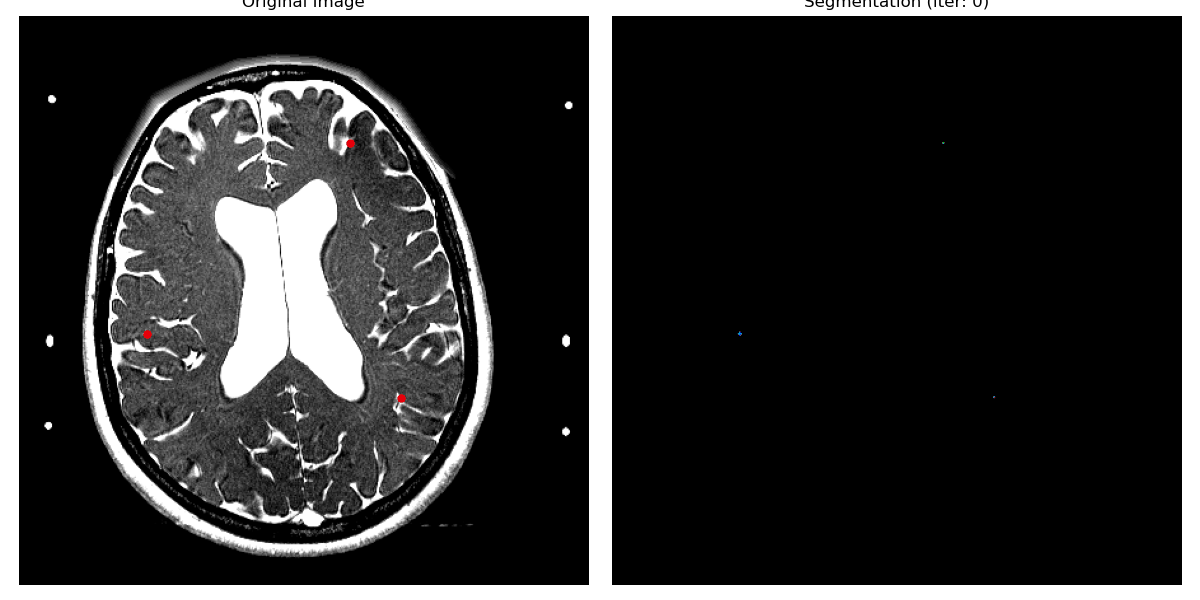

In [42]:
## SELECT PROPER SEEDS:
multi_seeds = (
    (250, 100),   # Seed 0 - adjust location
    (100, 260),   # Seed 1 - adjust location
    (300, 300),   # Seed 2 - adjust location
#    (p1, p2),
)

# Use same tau or adjust
# criterion_multi = make_similarity_criterion(mri_normalized, tau=0.08)   # conservative tau, slow, cannot cross subtle limits
criterion_multi = make_similarity_criterion(mri_normalized, tau=0.15)    # allows crossing a few more borders...

# Run segmentation
multi_seg = visualize_region_growing(
    mri_normalized,
    multi_seeds,
    criterion_multi,
    frame_step=1000,
    output_path="region_growing_multi_seed.gif",
    fps=5,
    max_iterations=80000,
    verbose=True
)

Individual region areas:
  Region 0 (seed at (250, 100)): 4218.99 mm²
  Region 1 (seed at (100, 260)): 2619.92 mm²
  Region 2 (seed at (300, 300)): 3631.76 mm²


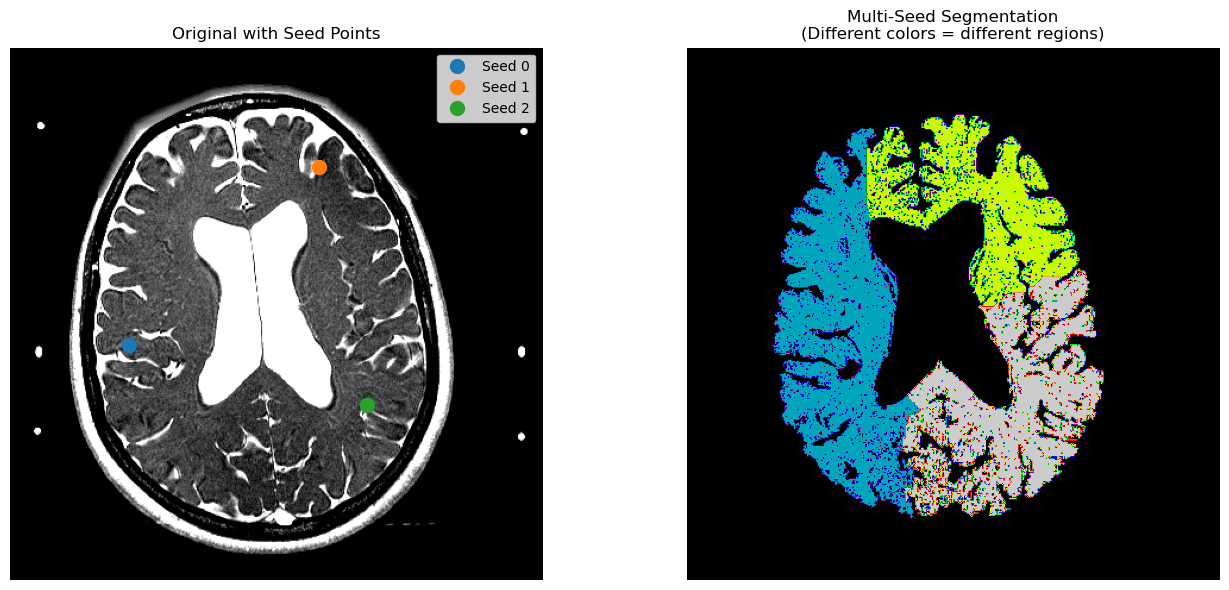

In [43]:
# Analyze the multi-seed segmentation
if multi_seg is not None:
    # Show each region's area
    areas = compute_region_areas(multi_seg, PIXEL_AREA_MM2)

    print("Individual region areas:")
    for rid, area in areas.items():
        print(f"  Region {rid} (seed at {multi_seeds[rid]}): {area:.2f} mm²")

    # Visualize to help identify which regions to merge
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(mri_normalized, cmap='gray')
    axes[0].set_title('Original with Seed Points')
    for i, s in enumerate(multi_seeds):
        axes[0].plot(s[1], s[0], 'o', markersize=10, label=f'Seed {i}')
    axes[0].legend()
    axes[0].axis('off')

    axes[1].imshow(multi_seg, cmap='nipy_spectral')
    axes[1].set_title('Multi-Seed Segmentation\n(Different colors = different regions)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Starting Multi-seed Region Growing with 3 seeds...
Iteration 0: 7/200704 pixels (0.0%)
Iteration 1000: 1105/200704 pixels (0.6%)
Iteration 2000: 2149/200704 pixels (1.1%)
Iteration 3000: 3182/200704 pixels (1.6%)
Iteration 4000: 4191/200704 pixels (2.1%)
Iteration 5000: 5213/200704 pixels (2.6%)
Iteration 6000: 6203/200704 pixels (3.1%)
Iteration 7000: 7217/200704 pixels (3.6%)
Iteration 8000: 8221/200704 pixels (4.1%)
Iteration 9000: 9258/200704 pixels (4.6%)
Iteration 10000: 10283/200704 pixels (5.1%)
Iteration 11000: 11295/200704 pixels (5.6%)
Iteration 12000: 12324/200704 pixels (6.1%)
Iteration 13000: 13328/200704 pixels (6.6%)
Iteration 14000: 14327/200704 pixels (7.1%)
Iteration 15000: 15342/200704 pixels (7.6%)
Iteration 16000: 16345/200704 pixels (8.1%)
Iteration 17000: 17364/200704 pixels (8.7%)
Iteration 18000: 18371/200704 pixels (9.2%)
Iteration 19000: 19360/200704 pixels (9.6%)
Iteration 20000: 20337/200704 pixels (10.1%)
Iteration 21000: 21315/200704 pixels (10.6%)
Itera

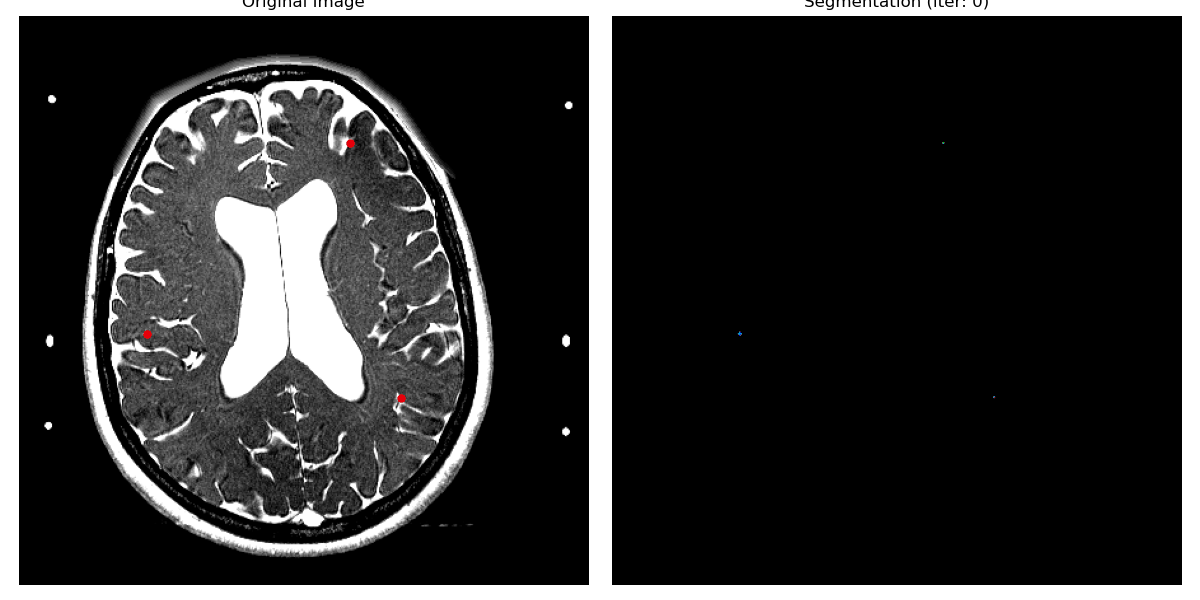


Individual Region Areas (Before Merging):
  Region 0 (Seed (250, 100)): 3798.78 mm²
  Region 1 (Seed (100, 260)): 2506.30 mm²
  Region 2 (Seed (300, 300)): 2600.36 mm²


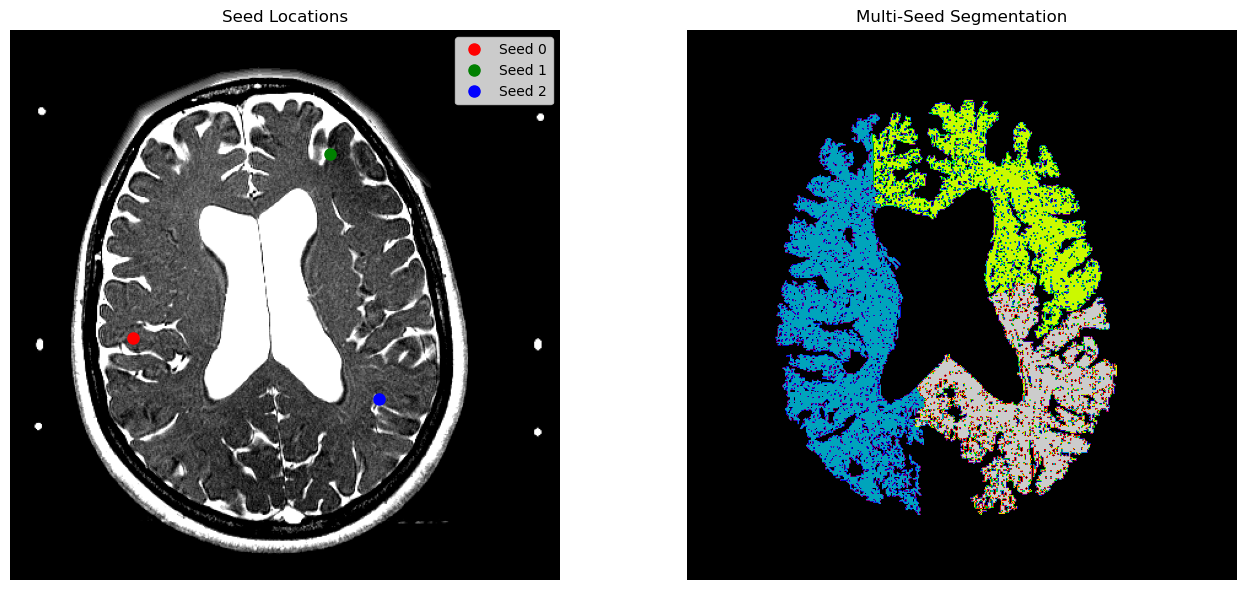


Merging regions [0, 2] (Ventricles)...
TOTAL VENTRICLE AREA: 6399.14 mm²


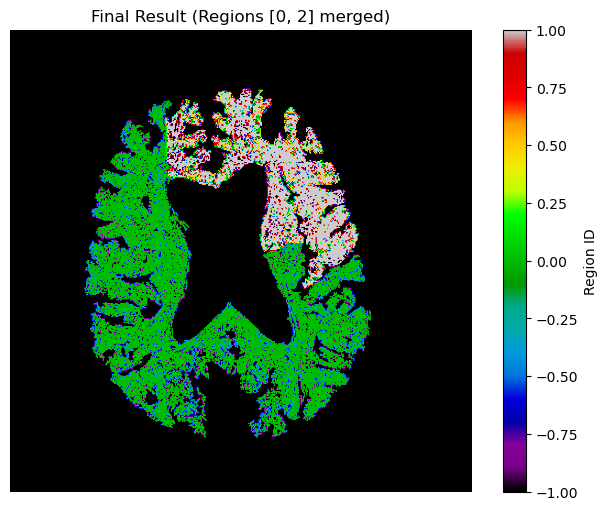

In [ ]:
# All the code in this last cell to run it individually and test changing something

# --- STEP 1: Define multiple seed points ---
# We select points for the left ventricle, gray matter, and right ventricle.
# Coordinates are in (row, col) format.
multi_seeds = (
    (250, 100),   # Seed 0 - adjust location
    (100, 260),   # Seed 1 - adjust location
    (300, 300),   # Seed 2 - adjust location
#    (p1, p2),
)

# Set similarity threshold (tau).
# 0.12 is tolerant enough to capture the full ventricle shape without leaking too much.
tau = 0.12 
criterion_multi = make_similarity_criterion(mri_normalized, tau=tau)

print(f"Starting Multi-seed Region Growing with {len(multi_seeds)} seeds...")

# --- STEP 2: Run Segmentation ---
multi_seg = visualize_region_growing(
    mri_normalized,
    multi_seeds,
    criterion_multi,
    frame_step=1000,
    output_path="region_growing_multi_seed.gif",
    fps=10,
    max_iterations=50000,
    verbose=True
)

# --- STEP 3: Analyze and Merge Regions ---
if multi_seg is not None:
    # Calculate area for each individual region before merging
    areas = compute_region_areas(multi_seg, PIXEL_AREA_MM2)
    
    print("\nIndividual Region Areas (Before Merging):")
    for rid, area in areas.items():
        print(f"  Region {rid} (Seed {multi_seeds[rid]}): {area:.2f} mm²")

    # Visualize the multi-seed result
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Original image with seed locations
    axes[0].imshow(mri_normalized, cmap='gray')
    axes[0].set_title('Seed Locations')
    colors = ['red', 'green', 'blue']
    for i, s in enumerate(multi_seeds):
        c = colors[i] if i < 3 else 'yellow'
        axes[0].plot(s[1], s[0], 'o', color=c, markersize=8, label=f'Seed {i}')
    axes[0].legend()
    axes[0].axis('off')
    
    # Plot 2: Segmentation result (different colors for different regions)
    axes[1].imshow(multi_seg, cmap='nipy_spectral', vmin=-1)
    axes[1].set_title('Multi-Seed Segmentation')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

    # --- STEP 4: Merge Ventricles ---
    # Based on the coordinates, Seed 0 and Seed 2 correspond to the ventricles.
    # We want to merge them into a single anatomical structure.
    labels_to_merge = [0, 2] 
    
    print(f"\nMerging regions {labels_to_merge} (Ventricles)...")
    
    # Apply merging: pixels from regions 0 and 2 will share the same label
    merged_seg = merge_regions(multi_seg, labels_to_merge)
    
    # Calculate the new combined areas
    final_areas = compute_region_areas(merged_seg, PIXEL_AREA_MM2)
    
    # The merged region usually takes the lowest ID (0 in this case)
    ventricle_area = final_areas[0]
    
    print("=" * 50)
    print(f"TOTAL VENTRICLE AREA: {ventricle_area:.2f} mm²")
    print("=" * 50)
    
    # Visualize final merged result
    plt.figure(figsize=(8, 6))
    plt.imshow(merged_seg, cmap='nipy_spectral', vmin=-1)
    plt.title(f'Final Result (Regions {labels_to_merge} merged)')
    plt.colorbar(label='Region ID')
    plt.axis('off')
    plt.show()